In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("../data/spotify_data.csv")
df.head()

,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1159764 entries, 0 to 1159763
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1159764 non-null  int64  
 1   artist_name       1159749 non-null  object 
 2   track_name        1159763 non-null  object 
 3   track_id          1159764 non-null  object 
 4   popularity        1159764 non-null  int64  
 5   year              1159764 non-null  int64  
 6   genre             1159764 non-null  object 
 7   danceability      1159764 non-null  float64
 8   energy            1159764 non-null  float64
 9   key               1159764 non-null  int64  
 10  loudness          1159764 non-null  float64
 11  mode              1159764 non-null  int64  
 12  speechiness       1159764 non-null  float64
 13  acousticness      1159764 non-null  float64
 14  instrumentalness  1159764 non-null  float64
 15  liveness          1159764 non-null  float64
 16  

In [4]:
df.describe()

,Unnamed: 0,popularity,year,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06
mean,6.590613e+05,1.838312e+01,2.011955e+03,5.374382e-01,6.396699e-01,5.287778e+00,-8.981353e+00,6.346533e-01,9.281477e-02,3.215370e-01,2.523489e-01,2.230189e-01,4.555636e-01,1.213771e+02,2.495618e+05,3.885879e+00
std,4.285492e+05,1.588554e+01,6.803901e+00,1.844780e-01,2.705009e-01,3.555197e+00,5.682215e+00,4.815275e-01,1.268409e-01,3.549872e-01,3.650731e-01,2.010707e-01,2.685190e-01,2.977975e+01,1.494262e+05,4.676967e-01
min,0.000000e+00,0.000000e+00,2.000000e+03,0.000000e+00,0.000000e+00,0.000000e+00,-5.810000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.073000e+03,0.000000e+00
25%,2.899408e+05,5.000000e+00,2.006000e+03,4.130000e-01,4.540000e-01,2.000000e+00,-1.082900e+01,0.000000e+00,3.710000e-02,6.400000e-03,1.050000e-06,9.790000e-02,2.260000e-01,9.879700e+01,1.810910e+05,4.000000e+00
50%,5.798815e+05,1.500000e+01,2.012000e+03,5.500000e-01,6.940000e-01,5.000000e+00,-7.450000e+00,1.000000e+00,5.070000e-02,1.470000e-01,1.760000e-03,1.340000e-01,4.380000e-01,1.219310e+02,2.257440e+05,4.000000e+00
75%,1.031689e+06,2.900000e+01,2.018000e+03,6.770000e-01,8.730000e-01,8.000000e+00,-5.276000e+00,1.000000e+00,8.900000e-02,6.400000e-01,6.140000e-01,2.920000e-01,6.740000e-01,1.399030e+02,2.869135e+05,4.000000e+00
max,1.473395e+06,1.000000e+02,2.023000e+03,9.930000e-01,1.000000e+00,1.100000e+01,6.172000e+00,1.000000e+00,9.710000e-01,9.960000e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.499930e+02,6.000495e+06,5.000000e+00


In [5]:
df.isnull().sum()

Unnamed: 0           0
artist_name         15
track_name           1
track_id             0
popularity           0
year                 0
genre                0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
duration_ms          0
time_signature       0
dtype: int64

In [6]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['Unnamed: 0', 'popularity', 'year', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature'],
      dtype='object')

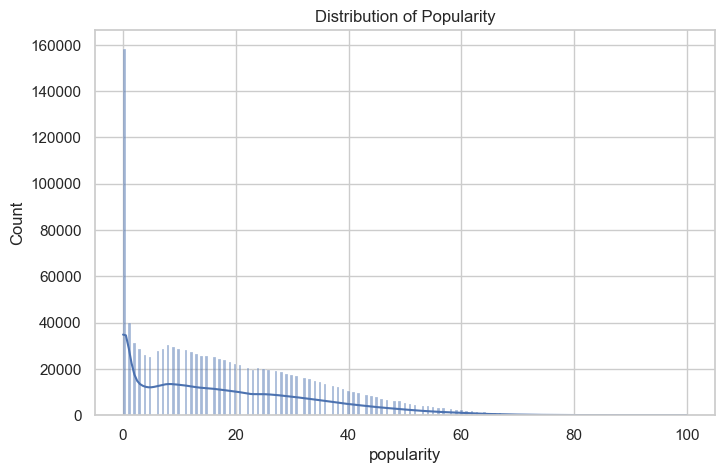

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], kde=True)
plt.title("Distribution of Popularity")
plt.show()

Dataset cleaning:

In [14]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1159748 entries, 0 to 1159763
Data columns (total 19 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   artist_name       1159748 non-null  object 
 1   track_name        1159748 non-null  object 
 2   track_id          1159748 non-null  object 
 3   popularity        1159748 non-null  int64  
 4   year              1159748 non-null  int64  
 5   genre             1159748 non-null  object 
 6   danceability      1159748 non-null  float64
 7   energy            1159748 non-null  float64
 8   key               1159748 non-null  int64  
 9   loudness          1159748 non-null  float64
 10  mode              1159748 non-null  int64  
 11  speechiness       1159748 non-null  float64
 12  acousticness      1159748 non-null  float64
 13  instrumentalness  1159748 non-null  float64
 14  liveness          1159748 non-null  float64
 15  valence           1159748 non-null  float64
 16  tempo

EDA core:

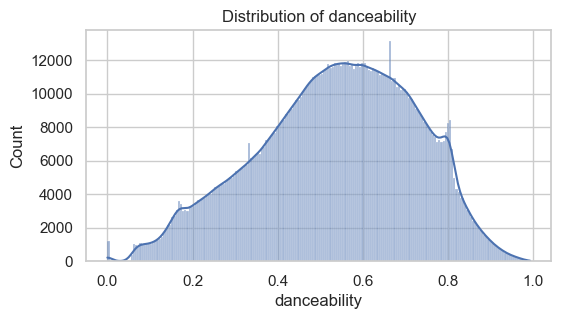

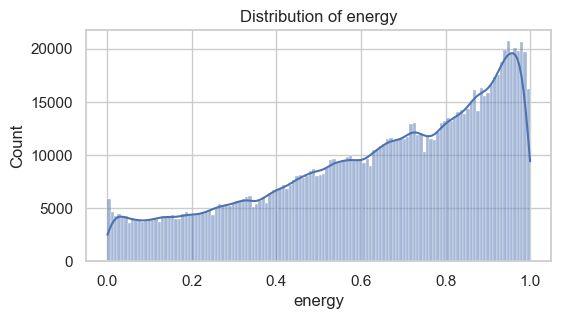

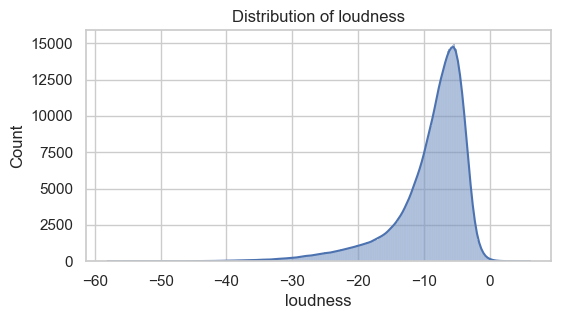

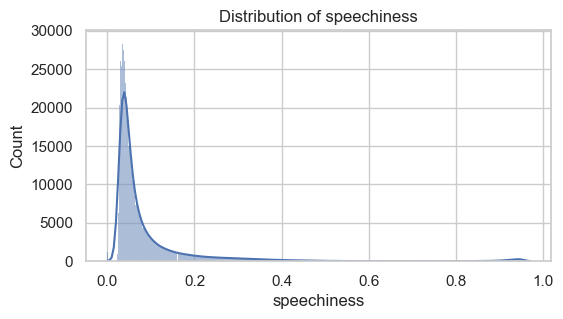

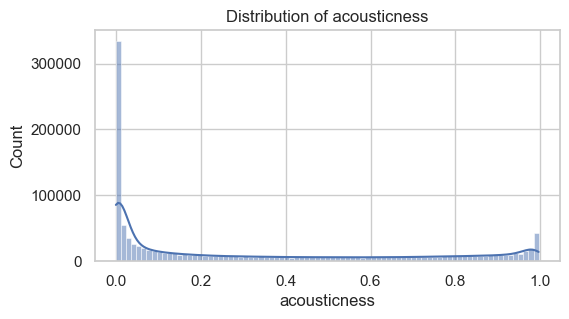

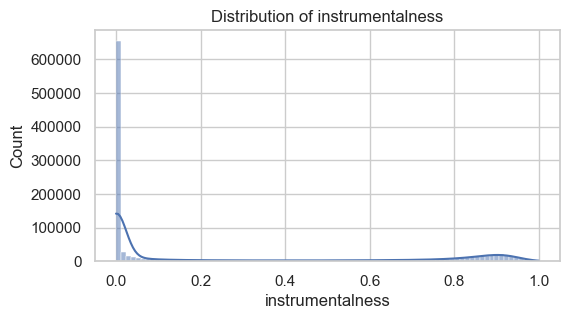

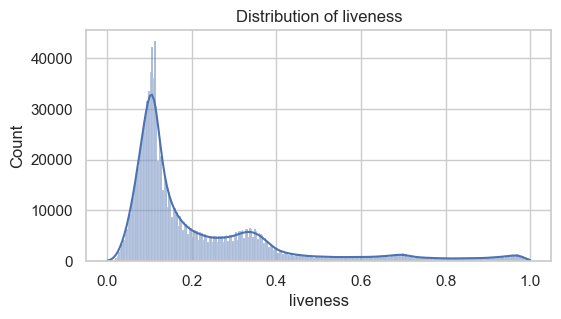

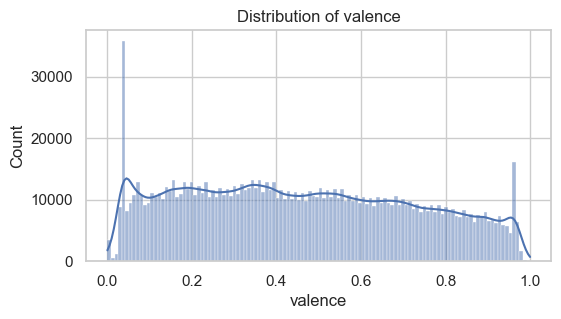

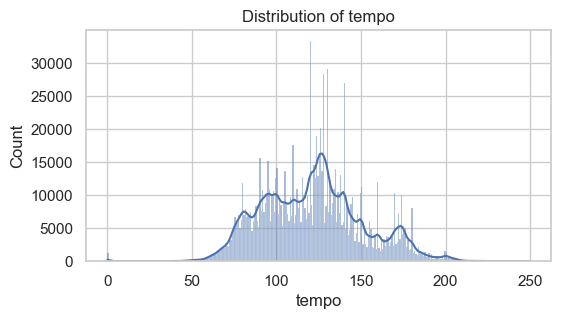

In [15]:
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

for f in features:
    plt.figure(figsize=(6,3))
    sns.histplot(df[f], kde=True)
    plt.title(f"Distribution of {f}")
    plt.show()

Boxplot outliers:

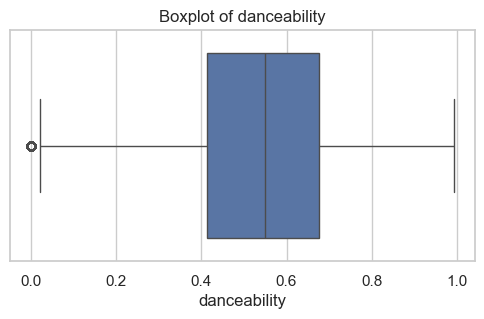

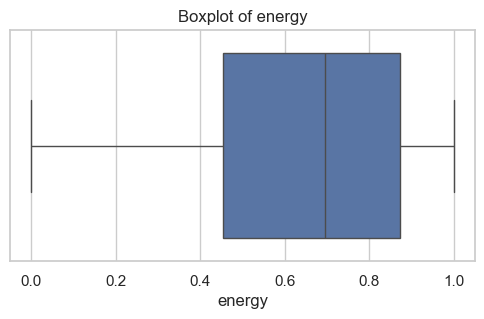

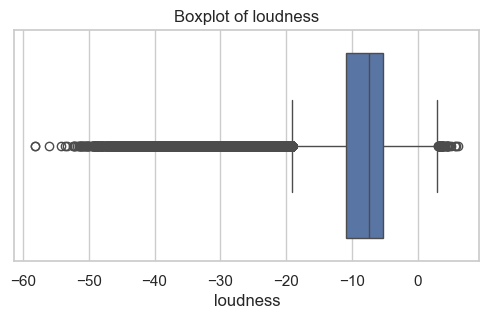

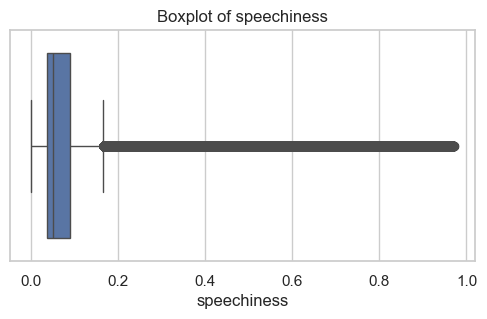

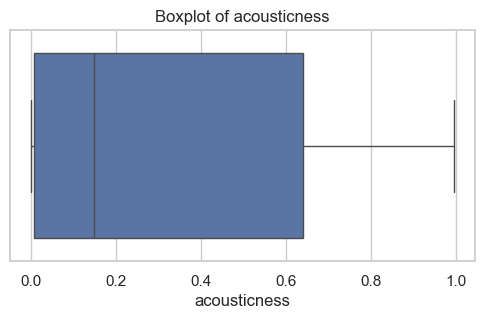

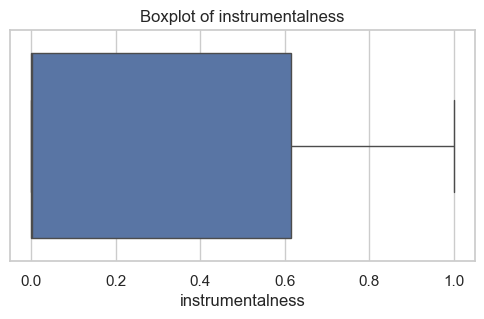

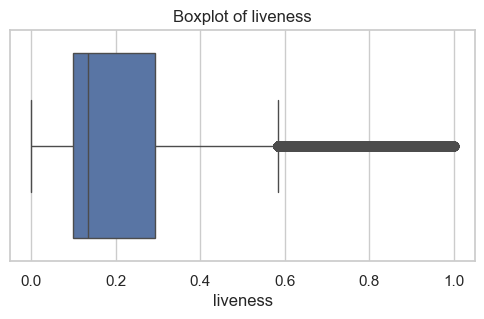

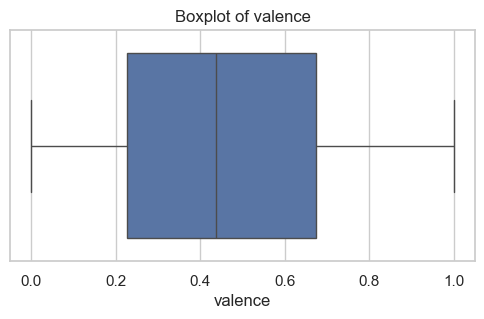

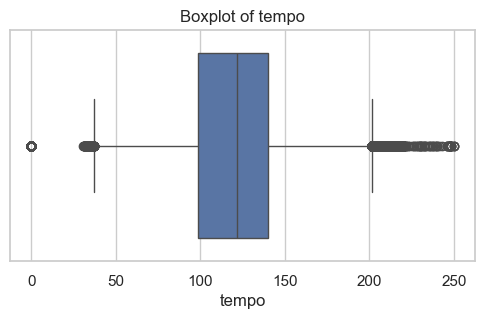

In [16]:
for f in features:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[f])
    plt.title(f"Boxplot of {f}")
    plt.show()

Correlation:

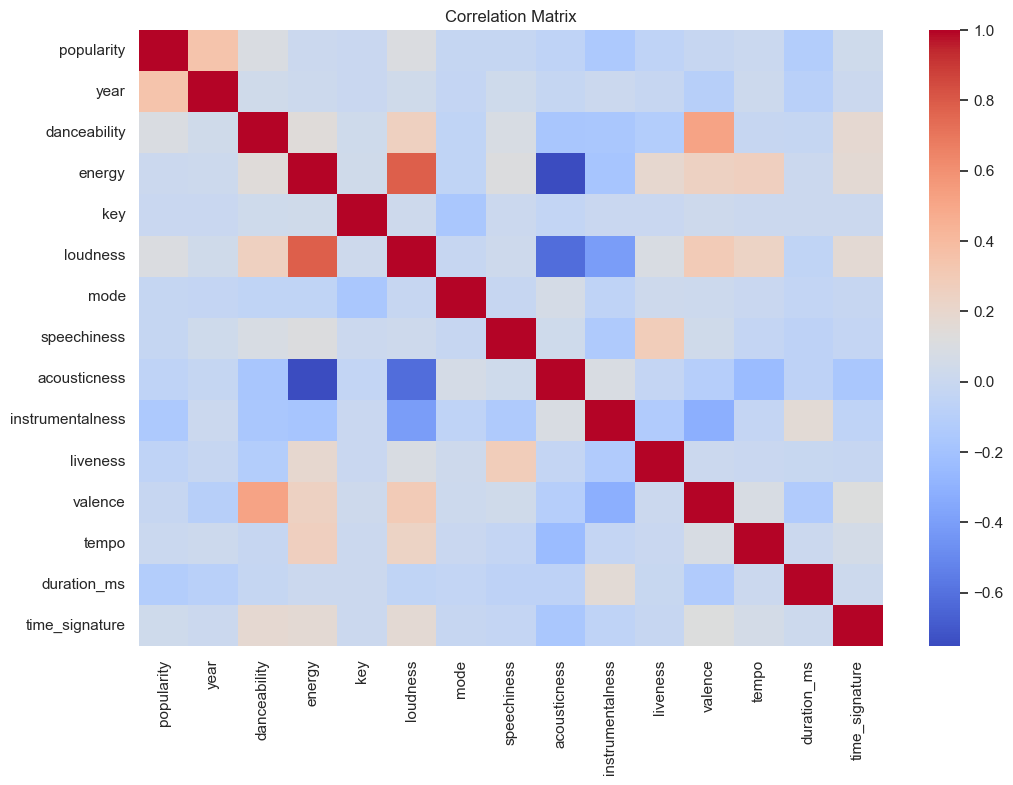

In [17]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

In [18]:
corr["popularity"].sort_values(ascending=False)

popularity          1.000000
year                0.345820
loudness            0.104100
danceability        0.098538
time_signature      0.030829
energy              0.009405
tempo               0.002567
key                 0.000389
valence            -0.018068
mode               -0.023836
speechiness        -0.024700
liveness           -0.056967
acousticness       -0.059181
duration_ms        -0.118490
instrumentalness   -0.152899
Name: popularity, dtype: float64

### Summary:

##### 1) year (0.34) is a strong factor influencing song popularity
* new tracks are more popular
* Spotify is promoting new
##### 2) danceability (~0.1) has a slight effect
##### 3) loudness (~0.1): loud tracks are a little more popular
##### 4) energy (~0.009):
* has almost NO EFFECT on popularity
* this breaks a popular myth
##### 5) instrumentalness (~ -0.15) & duration_ms (~ -0.11): they are less popular


### Popularity is moderately correlated with release year, indicating a bias toward newer songs.Instrumentalness and duration show negative correlation, meaning shorter vocal tracks tend to perform better.Surprisingly, energy has almost no impact on popularity.

Genres  visual comparing:

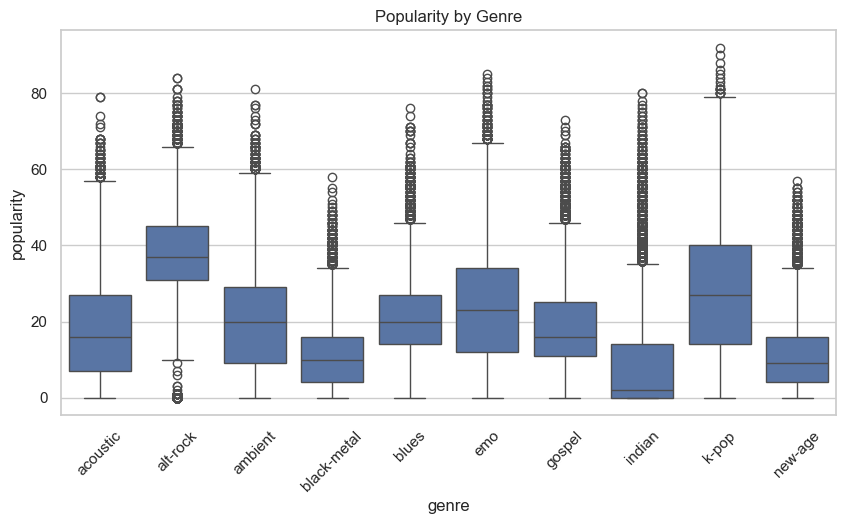

In [23]:
top_genres = df['genre'].value_counts().head(10).index
plt.figure(figsize=(10,5))
sns.boxplot(data=df[df['genre'].isin(top_genres)], x='genre', y='popularity')
plt.xticks(rotation=45)
plt.title("Popularity by Genre")
plt.show()

IS POPULAR?

In [34]:
df['is_popular'] = df['popularity'] > 50
df[['artist_name', 'track_name', 'year', 'is_popular']].head(20)

C:\Users\adilk\AppData\Local\Temp\ipykernel_9844\237388529.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_popular'] = df['popularity'] > 50


,artist_name,track_name,year,is_popular
0,Jason Mraz,I Won't Give Up,2012,True
1,Jason Mraz,93 Million Miles,2012,False
2,Joshua Hyslop,Do Not Let Me Go,2012,True
3,Boyce Avenue,Fast Car,2012,True
4,Andrew Belle,Sky's Still Blue,2012,True
5,Chris Smither,What They Say,2012,False
6,Matt Wertz,Walking in a Winter Wonderland,2012,False
7,Green River Ordinance,Dancing Shoes,2012,False
8,Jason Mraz,Living in the Moment,2012,False
9,Boyce Avenue,Heaven,2012,True


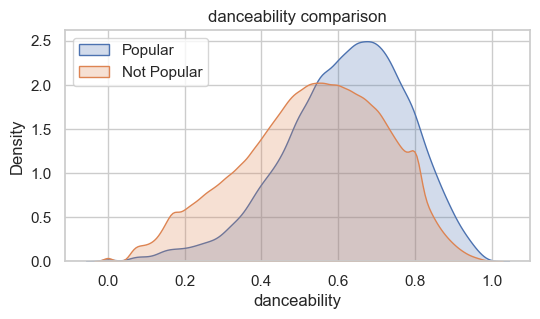

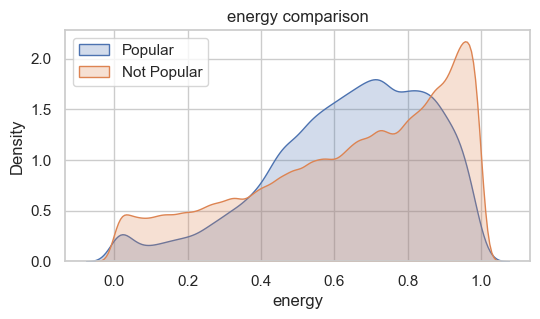

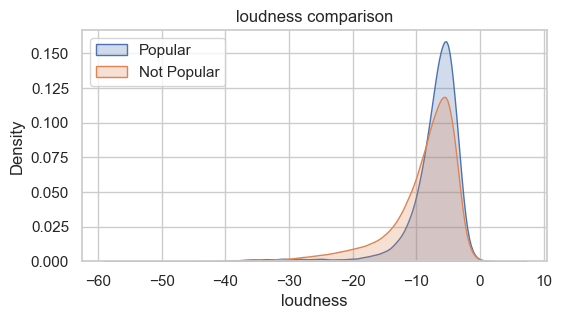

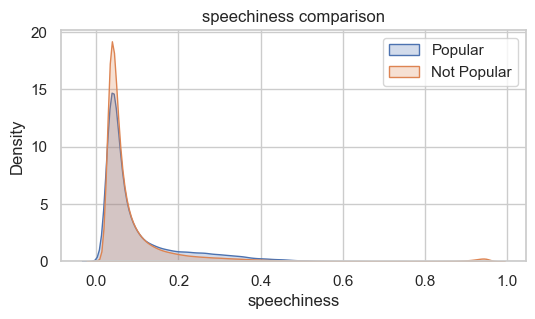

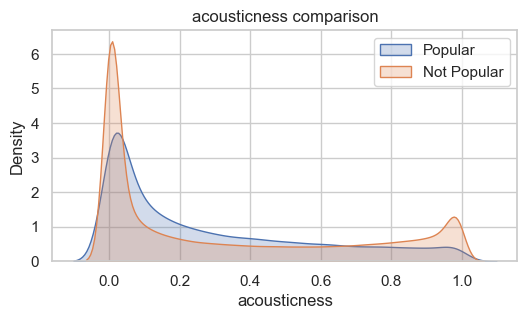

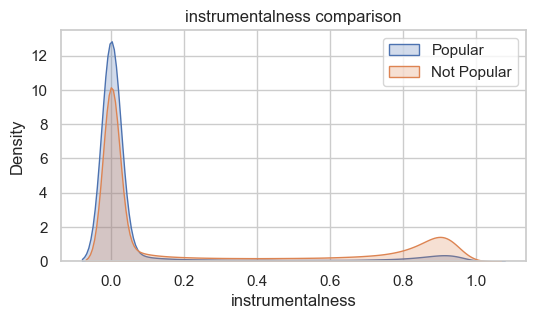

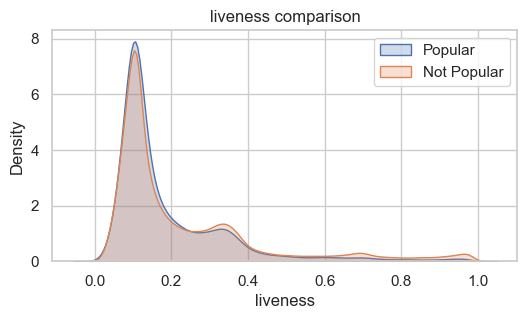

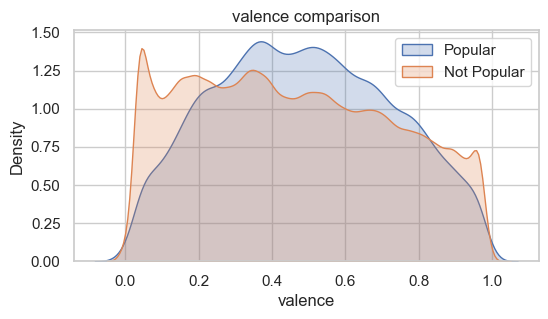

In [33]:
features = [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness',
    'instrumentalness', 'liveness',
    'valence'
]

for col in features:
    plt.figure(figsize=(6,3))
    sns.kdeplot(df[df['is_popular'] == 1][col], label='Popular', fill=True)
    sns.kdeplot(df[df['is_popular'] == 0][col], label='Not Popular', fill=True)
    plt.title(f"{col} comparison")
    plt.legend()
    plt.show()

In [35]:
from scipy.stats import ttest_ind

features = [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness',
    'instrumentalness', 'liveness',
    'valence'
]

for f in features:
    pop = df[df['is_popular'] == 1][f]
    not_pop = df[df['is_popular'] == 0][f]
    t_stat, p_value = ttest_ind(pop, not_pop)
    print(f"{f}:")
    print(f"  T-stat = {t_stat:.4f}")
    print(f"  P-value = {p_value:.6f}")
    print("-" * 30)

danceability:
  T-stat = 100.8084
  P-value = 0.000000
------------------------------
energy:
  T-stat = 0.0256
  P-value = 0.979538
------------------------------
loudness:
  T-stat = 63.8948
  P-value = 0.000000
------------------------------
speechiness:
  T-stat = 9.6991
  P-value = 0.000000
------------------------------
acousticness:
  T-stat = -27.6413
  P-value = 0.000000
------------------------------
instrumentalness:
  T-stat = -107.0273
  P-value = 0.000000
------------------------------
liveness:
  T-stat = -36.7950
  P-value = 0.000000
------------------------------
valence:
  T-stat = 24.2269
  P-value = 0.000000
------------------------------


Cohen’s d:

In [36]:
def cohens_d(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2)

for f in features:
    pop = df[df['is_popular'] == 1][f]
    not_pop = df[df['is_popular'] == 0][f]
    d = cohens_d(pop, not_pop)
    print(f"{f}: Cohen's d = {d:.4f}")

danceability: Cohen's d = 0.5005
energy: Cohen's d = 0.0001
loudness: Cohen's d = 0.3216
speechiness: Cohen's d = 0.0499
acousticness: Cohen's d = -0.1404
instrumentalness: Cohen's d = -0.5953
liveness: Cohen's d = -0.1906
valence: Cohen's d = 0.1195


In [37]:
results = []

for col in features:
    pop = df[df['is_popular'] == 1][col]
    not_pop = df[df['is_popular'] == 0][col]

    d = cohens_d(pop, not_pop)
    results.append((col, d))

sorted(results, key=lambda x: abs(x[1]), reverse=True)

[('instrumentalness', np.float64(-0.5952957202198136)),
 ('danceability', np.float64(0.5004583186792051)),
 ('loudness', np.float64(0.321604957970781)),
 ('liveness', np.float64(-0.1906324279055637)),
 ('acousticness', np.float64(-0.14038240351562575)),
 ('valence', np.float64(0.11945748622200009)),
 ('speechiness', np.float64(0.049925945753217175)),
 ('energy', np.float64(0.00013104849689834456))]

### General insight:
#### The analysis shows that not all audio features significantly impact song popularity. While many variables are statistically significant, only a few demonstrate meaningful effect sizes.

### Top factors:
#### Instrumentalness has the strongest negative effect (d = -0.59), indicating that popular songs are significantly less instrumental and more vocal-oriented. Danceability shows a strong positive effect (d = 0.50), suggesting that more danceable tracks tend to be more popular. Loudness has a moderate positive effect (d = 0.32), meaning louder tracks are slightly more popular.

### Weak/No effect:

#### Energy shows no meaningful impact on popularity (d ≈ 0), despite common assumptions. Speechiness, valence, and acousticness have only weak effects.

In [38]:
df[features].std().sort_values(ascending=False)

loudness            5.682203
instrumentalness    0.365070
acousticness        0.354987
energy              0.270499
valence             0.268517
liveness            0.201071
danceability        0.184475
speechiness         0.126842
dtype: float64

#### Duration outliers:

In [41]:
df[df['duration_ms'] > 1000000]

,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,is_popular
1150,Fela Kuti,Confusion Break Bones - Live,3W63heEIBqoSIbbLfVS8EE,6,2012,afrobeat,0.4080,0.686000,2,-9.283,0,0.0484,0.282000,0.0546,0.9700,0.3820,123.553,2429560,3,False
3057,Brian Eno,LUX 1,7j4N7LQZHGiNvPELPuNCPu,24,2012,ambient,0.0680,0.022500,0,-27.637,1,0.0429,0.971000,0.8650,0.0854,0.0340,68.803,1160557,1,False
3122,Brian Eno,LUX 4,5yVDoQzGtrRWiexs8qAZFy,20,2012,ambient,0.0963,0.015500,9,-29.832,0,0.0453,0.975000,0.9250,0.0816,0.0302,72.072,1107913,1,False
3136,Brian Eno,LUX 3,5VV3XBEeD9jN3B4JywyFYw,20,2012,ambient,0.1160,0.027900,9,-27.119,0,0.0409,0.971000,0.9240,0.0956,0.0332,72.569,1159013,3,False
3157,Dmitri Shostakovich,"Symphony No. 7 in C Major, Op. 60 ""Leningrad"":...",1B5PS6AZIdzIgTcDvxJZpP,25,2012,ambient,0.2080,0.059800,0,-20.934,1,0.0418,0.730000,0.5330,0.1030,0.0635,141.390,1724812,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158879,Carlos Perón,La salle blanche - Version originale,2BqkrhfveIRTo2PwNt7VW9,12,2011,techno,0.3620,0.625000,10,-9.183,0,0.0348,0.241000,0.6360,0.1110,0.1310,106.762,2313173,4,False
1158986,Schiller,Zenit (feat. Klaus Schulze),63J6glG0l2YgqONow1t2ZP,1,2011,techno,0.5090,0.806000,10,-13.016,0,0.0331,0.110000,0.9400,0.3680,0.6220,95.005,1088080,4,False
1159008,Scott Brown,Hardcore Heaven 4 - Part 1 - Continuous Mix by...,5aJTGuA6nwgsC1QsuvrdRi,8,2011,techno,0.4050,0.963000,7,-6.260,1,0.0626,0.000371,0.4540,0.0750,0.1480,172.106,4608947,4,False
1159403,The Orb,Battersea Bunches - Original Soundtrack,06g5N3tKFwFb2Q8qVBQXlu,5,2011,trip-hop,0.2960,0.427000,11,-17.521,1,0.1870,0.472000,0.7880,0.2470,0.1320,78.272,1047667,4,False


In [43]:
duration_outliers = len(df['duration_ms'] > 1000000)
duration_outliers

1159748